# Customer churn — exploratory data analysis

This notebook audits the supplied invoice data before feature engineering and modelling. The central question is whether information from a customer's first two months can predict whether that customer will be `noise` (churned) after 12 months.

The notebook is deliberately structured around modelling decisions:

1. Establish the observation grain and target grain
2. Identify data-quality issues and possible leakage
3. Quantify churn at the **customer** level
4. Explore early-life commercial and product signals
5. Compare training and validation populations
6. Translate findings into a defensible validation and modelling plan.

> Note: Associations in this notebook are descriptive, not causal.

## 1. Setup

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

ID_COLUMN = "FK_DWH_CUSTOMERS"
TARGET_COLUMN = "noise"
RANDOM_STATE = 42

In [3]:
# This makes the notebook work when launched from either the repository root
# or the notebooks directory.
search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (path for path in search_roots if (path / "data" / "training.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate data/training.csv from the current directory.")

TRAIN_PATH = REPO_ROOT / "data" / "training.csv"
VALIDATION_PATH = REPO_ROOT / "data" / "validation.csv"

train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)

print("Loaded data/training.csv and data/validation.csv")
print(f"Training shape:   {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Validation shape: {validation.shape[0]:,} rows x {validation.shape[1]} columns")

Loaded data/training.csv and data/validation.csv
Training shape:   93,589 rows x 13 columns
Validation shape: 42,055 rows x 12 columns


In [4]:
train.head()

,PK_INVOICES,FK_DATE_INVOICE,CUSTOMER_START_DATE,TENURE,FLG_DWH_CUSTOMER_IS_BUSINESS,FK_DWH_CUSTOMERS,FK_SUBSCRIPTIONS,PRODUCT_GROUP,PRODUCT_SUBCATEGORY,mrr,ORIGIN_SUBGROUP,ORIGIN_GROUP,noise
0,55302679,20230124,20230101,1,1,3029671,35372994,Local ccTLD,Domain Names,0.001,Affiliate Marketing,Paid Traffic,True
1,53939194,20230124,20230101,1,1,3029671,91915286,Local ccTLD,Domain Names,0.001,Affiliate Marketing,Paid Traffic,True
2,20650401,20230131,20230101,1,1,3029671,28979694,E-mail,E-mail,0.001,Affiliate Marketing,Paid Traffic,True
3,20650401,20230131,20230101,0,1,3029671,28979694,E-mail,E-mail,0.001,Affiliate Marketing,Paid Traffic,True
4,53939194,20230124,20230101,0,1,3029671,91915286,Local ccTLD,Domain Names,0.001,Affiliate Marketing,Paid Traffic,True


## 2. Schema and observation grain

Each row is an invoice-product observation, while the requested prediction is one label per customer. A customer can therefore appear on many rows. Computing churn directly from rows would overweight customers with more products or invoices; all target statistics, train/test splits, and predictions must operate at customer level.

PK_INVOICES                                    2832
FK_DATE_INVOICE                      20,240,123.000
CUSTOMER_START_DATE                  20,240,101.000
TENURE                                        0.000
FLG_DWH_CUSTOMER_IS_BUSINESS                  1.000
FK_DWH_CUSTOMERS                     65,703,850.000
FK_SUBSCRIPTIONS                     12,666,515.000
PRODUCT_GROUP                           Local ccTLD
PRODUCT_SUBCATEGORY                    Domain Names
mrr                                           0.001
ORIGIN_SUBGROUP                 Pay Per Click (PPC)
ORIGIN_GROUP                           Paid Traffic
Name: 0, dtype: object

In [20]:
def schema_summary(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "missing_pct": df.isna().mean().mul(100),
            "mode": validation.mode().iloc[0],
            "unique_values": df.nunique(dropna=False),
        }
    )

schema = pd.concat(
    {"training": schema_summary(train), "validation": schema_summary(validation)},
    axis=1,
)
schema

training                      \
                                dtype missing missing_pct   
CUSTOMER_START_DATE             int64       0       0.000   
FK_DATE_INVOICE                 int64       0       0.000   
FK_DWH_CUSTOMERS                int64       0       0.000   
FK_SUBSCRIPTIONS                int64       0       0.000   
FLG_DWH_CUSTOMER_IS_BUSINESS    int64       0       0.000   
ORIGIN_GROUP                      str     403       0.431   
ORIGIN_SUBGROUP                   str     403       0.431   
PK_INVOICES                     int64       0       0.000   
PRODUCT_GROUP                     str       0       0.000   
PRODUCT_SUBCATEGORY               str       0       0.000   
TENURE                          int64       0       0.000   
mrr                           float64       0       0.000   
noise                            bool       0       0.000   

                                                                validation  \
                                             mode unique_values      dtype   
CUSTOMER_START_DATE                20,240,101.000             6      int64   
FK_DATE_INVOICE                    20,240,123.000           457      int64   
FK_DWH_CUSTOMERS                   65,703,850.000         22674      int64   
FK_SUBSCRIPTIONS                   12,666,515.000         48488      int64   
FLG_DWH_CUSTOMER_IS_BUSINESS                1.000             2      int64   
ORIGIN_GROUP                         Paid Traffic             4        str   
ORIGIN_SUBGROUP               Pay Per Click (PPC)             7        str   
PK_INVOICES                                  2832         52718      int64   
PRODUCT_GROUP                         Local ccTLD            26        str   
PRODUCT_SUBCATEGORY                  Domain Names            18        str   
TENURE                                      0.000            76      int64   
mrr                                         0.001          2173    float64   
noise                                         NaN             2        NaN   

                                                                       \
                             missing missing_pct                 mode   
CUSTOMER_START_DATE            0.000       0.000       20,240,101.000   
FK_DATE_INVOICE                0.000       0.000       20,240,123.000   
FK_DWH_CUSTOMERS               0.000       0.000       65,703,850.000   
FK_SUBSCRIPTIONS               0.000       0.000       12,666,515.000   
FLG_DWH_CUSTOMER_IS_BUSINESS   0.000       0.000                1.000   
ORIGIN_GROUP                  36.000       0.086         Paid Traffic   
ORIGIN_SUBGROUP               36.000       0.086  Pay Per Click (PPC)   
PK_INVOICES                    0.000       0.000                 2832   
PRODUCT_GROUP                  0.000       0.000          Local ccTLD   
PRODUCT_SUBCATEGORY            0.000       0.000         Domain Names   
TENURE                         0.000       0.000                0.000   
mrr                            0.000       0.000                0.001   
noise                            NaN         NaN                  NaN   

                                            
                             unique_values  
CUSTOMER_START_DATE                  3.000  
FK_DATE_INVOICE                    209.000  
FK_DWH_CUSTOMERS                11,590.000  
FK_SUBSCRIPTIONS                22,098.000  
FLG_DWH_CUSTOMER_IS_BUSINESS         2.000  
ORIGIN_GROUP                         4.000  
ORIGIN_SUBGROUP                      7.000  
PK_INVOICES                     24,328.000  
PRODUCT_GROUP                       21.000  
PRODUCT_SUBCATEGORY                 15.000  
TENURE                               2.000  
mrr                                804.000  
noise                                  NaN

In [21]:
grain_summary = pd.DataFrame(
    {
        "training": [
            len(train),
            train[ID_COLUMN].nunique(),
            train["PK_INVOICES"].nunique(),
            train["FK_SUBSCRIPTIONS"].nunique(),
        ],
        "validation": [
            len(validation),
            validation[ID_COLUMN].nunique(),
            validation["PK_INVOICES"].nunique(),
            validation["FK_SUBSCRIPTIONS"].nunique(),
        ],
    },
    index=["rows", "customers", "invoices", "subscriptions"],
)
grain_summary

,training,validation
rows,93589,42055
customers,22674,11590
invoices,52718,24328
subscriptions,48488,22098


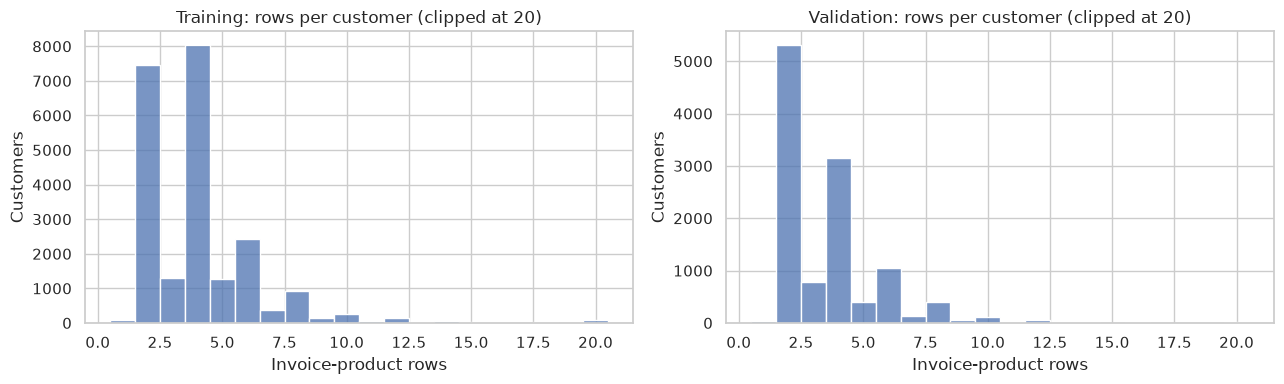

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, df) in zip(axes, [("Training", train), ("Validation", validation)]):
    rows_per_customer = df.groupby(ID_COLUMN).size()
    sns.histplot(rows_per_customer.clip(upper=20), discrete=True, ax=ax)
    ax.set(
        title=f"{name}: rows per customer (clipped at 20)",
        xlabel="Invoice-product rows",
        ylabel="Customers",
    )
plt.tight_layout()

## 3. Target audit

Before modelling, it must be verified that each customer has exactly one target value. Any conflicting label is an entity-definition problem, not a modelling problem, and should be resolved explicitly.

In [23]:
target_audit = (
    train.groupby(ID_COLUMN)
    .agg(
        target=(TARGET_COLUMN, "first"),
        target_nunique=(TARGET_COLUMN, "nunique"),
        row_count=(TARGET_COLUMN, "size"),
    )
)
ambiguous_targets = target_audit.loc[target_audit["target_nunique"] != 1]
consistent_targets = target_audit.loc[target_audit["target_nunique"] == 1, "target"]

print(f"Customers with conflicting targets: {len(ambiguous_targets):,}")
print(f"Row-level churn rate:      {train[TARGET_COLUMN].mean():.1%}")
print(f"Customer-level churn rate: {consistent_targets.mean():.1%}")
ambiguous_targets

Customers with conflicting targets: 1
Row-level churn rate:      58.9%
Customer-level churn rate: 62.1%


,target,target_nunique,row_count
FK_DWH_CUSTOMERS,,,
10147248,False,2,10


In [43]:
# View samples from this user
train.loc[train["FK_DWH_CUSTOMERS"]==10147248]

,PK_INVOICES,FK_DATE_INVOICE,CUSTOMER_START_DATE,TENURE,FLG_DWH_CUSTOMER_IS_BUSINESS,FK_DWH_CUSTOMERS,FK_SUBSCRIPTIONS,PRODUCT_GROUP,PRODUCT_SUBCATEGORY,mrr,ORIGIN_SUBGROUP,ORIGIN_GROUP,noise
29328,75380992,20230104,20230101,1,1,10147248,94391864,Local ccTLD,Domain Names,0.093,Pay Per Click (PPC),Paid Traffic,False
29329,26839207,20230104,20230101,1,1,10147248,39121336,.com,Domain Names,0.093,Pay Per Click (PPC),Paid Traffic,False
29330,75380992,20230104,20230101,0,1,10147248,94391864,Local ccTLD,Domain Names,0.093,Pay Per Click (PPC),Paid Traffic,False
29331,26839207,20230104,20230101,0,1,10147248,39121336,.com,Domain Names,0.093,Pay Per Click (PPC),Paid Traffic,False
29332,87983536,20230104,20230101,0,1,10147248,64448310,E-mail,E-mail,2.256,Pay Per Click (PPC),Paid Traffic,False
43110,53640051,20230204,20230201,1,1,10147248,97962736,Local ccTLD,Domain Names,0.094,Pay Per Click (PPC),Paid Traffic,True
43111,1069301,20230204,20230201,1,1,10147248,61657077,.com,Domain Names,0.094,Pay Per Click (PPC),Paid Traffic,True
43112,53640051,20230204,20230201,0,1,10147248,97962736,Local ccTLD,Domain Names,0.093,Pay Per Click (PPC),Paid Traffic,True
43113,1069301,20230204,20230201,0,1,10147248,61657077,.com,Domain Names,0.093,Pay Per Click (PPC),Paid Traffic,True
43114,99634071,20230204,20230201,0,1,10147248,54665080,E-mail,E-mail,2.247,Pay Per Click (PPC),Paid Traffic,True


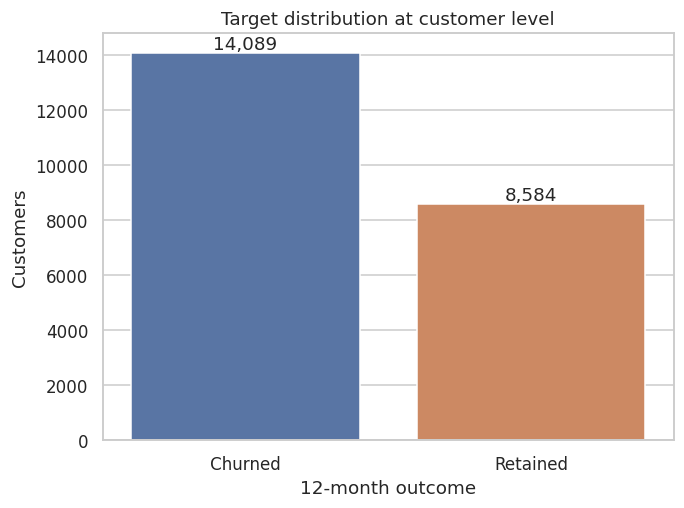

In [8]:
target_counts = consistent_targets.value_counts().rename(index={False: "Retained", True: "Churned"})
ax = sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, legend=False)
ax.set(title="Target distribution at customer level", xlabel="12-month outcome", ylabel="Customers")
for patch, value in zip(ax.patches, target_counts.values):
    ax.annotate(f"{value:,}", (patch.get_x() + patch.get_width() / 2, value), ha="center", va="bottom")
plt.tight_layout()

**Decision:** exclude the single ambiguous customer from supervised training as there is no hint of this behaviour. Taking the first label or a majority vote would silently manufacture ground truth. The class balance is not extreme, but accuracy alone will still be insufficient: a majority-class prediction is already a meaningful baseline.

## 4. Data-quality checks

In [28]:
missingness = pd.concat(
    {
        "training_missing": train.isna().sum(),
        "training_missing_pct": train.isna().mean().mul(100),
        "validation_missing": validation.isna().sum(),
        "validation_missing_pct": validation.isna().mean().mul(100),
    },
    axis=1,
).fillna(0).sort_values("training_missing_pct", ascending=False)
missingness.loc[missingness.max(axis=1) > 0]

,training_missing,training_missing_pct,validation_missing,validation_missing_pct
ORIGIN_GROUP,403,0.431,36.000,0.086
ORIGIN_SUBGROUP,403,0.431,36.000,0.086


In [29]:
def identifier_audit(df: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "exact_duplicate_rows": int(df.duplicated().sum()),
            "invoice_ids_linked_to_multiple_customers": int(
                (df.groupby("PK_INVOICES")[ID_COLUMN].nunique() > 1).sum()
            ),
            "subscription_ids_linked_to_multiple_customers": int(
                (df.groupby("FK_SUBSCRIPTIONS")[ID_COLUMN].nunique() > 1).sum()
            ),
            "customer_ids_linked_to_multiple_start_dates": int(
                (df.groupby(ID_COLUMN)["CUSTOMER_START_DATE"].nunique() > 1).sum()
            ),
        }
    )

id_audit = pd.concat(
    {"training": identifier_audit(train), "validation": identifier_audit(validation)},
    axis=1,
)
id_audit

,training,validation
exact_duplicate_rows,0,0
invoice_ids_linked_to_multiple_customers,14,2
subscription_ids_linked_to_multiple_customers,16,4
customer_ids_linked_to_multiple_start_dates,2,1


In [30]:
overlap_audit = pd.Series(
    {
        "customer_ids": len(set(train[ID_COLUMN]) & set(validation[ID_COLUMN])),
        "invoice_ids": len(set(train["PK_INVOICES"]) & set(validation["PK_INVOICES"])),
        "subscription_ids": len(set(train["FK_SUBSCRIPTIONS"]) & set(validation["FK_SUBSCRIPTIONS"])),
    },
    name="train_validation_overlap",
)
overlap_audit.to_frame()

,train_validation_overlap
customer_ids,2
invoice_ids,16
subscription_ids,18


Identifier collisions deserve investigation. Raw invoice, subscription, and customer identifiers should not be model features: even when unique, identifiers usually encode no stable business behavior and can encourage memorisation. Cross-split overlap must also be handled before any internal validation to prevent leakage. From here, we can conclude the train-validation split sets were not properly done.

In [12]:
def with_parsed_dates(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["invoice_date"] = pd.to_datetime(
        result["FK_DATE_INVOICE"].astype(str), format="%Y%m%d", errors="coerce"
    )
    result["customer_start_date"] = pd.to_datetime(
        result["CUSTOMER_START_DATE"].astype(str), format="%Y%m%d", errors="coerce"
    )
    return result

train_dates = with_parsed_dates(train)
validation_dates = with_parsed_dates(validation)

date_coverage = pd.DataFrame(
    {
        "training": [
            train_dates["invoice_date"].min(),
            train_dates["invoice_date"].max(),
            train_dates["customer_start_date"].min(),
            train_dates["customer_start_date"].max(),
        ],
        "validation": [
            validation_dates["invoice_date"].min(),
            validation_dates["invoice_date"].max(),
            validation_dates["customer_start_date"].min(),
            validation_dates["customer_start_date"].max(),
        ],
    },
    index=["min_invoice_date", "max_invoice_date", "min_customer_start", "max_customer_start"],
)
date_coverage

,training,validation
min_invoice_date,2013-01-16,2017-03-31
max_invoice_date,2025-09-19,2025-10-23
min_customer_start,2023-01-01,2024-01-01
max_customer_start,2023-06-01,2024-03-01


In [ ]:
def tenure_bucket(value: int) -> str:
    if value < 0:
        return "negative"
    if value in (0, 1):
        return str(value)
    return "greater_than_1"

tenure_summary = pd.concat(
    {
        name: df["TENURE"].map(tenure_bucket).value_counts()
        for name, df in [("training", train), ("validation", validation)]
    },
    axis=1,
).fillna(0).astype(int)

negative_tenure_customers = train.loc[train["TENURE"] < 0, ID_COLUMN].nunique()
print(f"Training customers with negative-tenure rows: {negative_tenure_customers:,}")
tenure_summary

Training customers with negative-tenure rows: 30


,training,validation
TENURE,,
0,46977,21515
1,45145,20540
negative,1467,0


The brief says tenure should be 0 or 1, but training contains negative values. These rows should be discarded from the training step if there are no hints of which are their real value. Also note that `FK_DATE_INVOICE` appears to be the original invoice date and can remain constant across monthly observations; it should not automatically be treated as the snapshot month. Negative MRR values are plausible credits/refunds and should be retained as a potentially useful signal rather than removed as outliers.

In [31]:
mrr_quality = pd.DataFrame(
    {
        "training": [
            (train["mrr"] < 0).sum(),
            (train["mrr"] == 0).sum(),
            train["mrr"].min(),
            train["mrr"].median(),
            train["mrr"].quantile(0.99),
            train["mrr"].max(),
        ],
        "validation": [
            (validation["mrr"] < 0).sum(),
            (validation["mrr"] == 0).sum(),
            validation["mrr"].min(),
            validation["mrr"].median(),
            validation["mrr"].quantile(0.99),
            validation["mrr"].max(),
        ],
    },
    index=["negative_rows", "zero_rows", "minimum", "median", "p99", "maximum"],
)
mrr_quality

,training,validation
negative_rows,671.000,277.000
zero_rows,0.000,0.000
minimum,-202.078,-142.643
median,0.001,0.001
p99,12.407,10.513
maximum,745.063,194.543


## 5. Categorical coverage

Categories found only in validation will be unknown to a model trained on the training set. The modelling pipeline must therefore use an encoder that safely ignores unseen values.

In [15]:
categorical_columns = [
    "PRODUCT_GROUP",
    "PRODUCT_SUBCATEGORY",
    "ORIGIN_SUBGROUP",
    "ORIGIN_GROUP",
]

category_coverage = []
for column in categorical_columns:
    train_values = set(train[column].dropna())
    validation_values = set(validation[column].dropna())
    category_coverage.append(
        {
            "column": column,
            "training_unique": len(train_values),
            "validation_unique": len(validation_values),
            "training_only": sorted(train_values - validation_values),
            "validation_only": sorted(validation_values - train_values),
        }
    )
pd.DataFrame(category_coverage).set_index("column")

,training_unique,validation_unique,training_only,validation_only
column,,,,
PRODUCT_GROUP,26,21,"[Administration Panels, Connectivity Solutions...","[Microsoft SPLA, URL Forwarding]"
PRODUCT_SUBCATEGORY,18,15,"[Connectivity, Managed Servers, Shared Windows...",[URL Forwarding]
ORIGIN_SUBGROUP,6,6,[],[]
ORIGIN_GROUP,3,3,[],[]


## 6. Build an exploratory customer-level table

The following function is intentionally kept in the notebook during exploration. Once its definitions are agreed, it should move into `src/` and be covered by unit tests so the exact same transformation is used for training and validation. Only tenure 0 and 1 contribute to month-specific features.

In [37]:
def first_non_null(series: pd.Series):
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) else np.nan


def build_customer_features(df: pd.DataFrame, include_target: bool) -> pd.DataFrame:
    base = df.groupby(ID_COLUMN, sort=False).agg(
        row_count=("PK_INVOICES", "size"),
        invoice_count=("PK_INVOICES", "nunique"),
        subscription_count=("FK_SUBSCRIPTIONS", "nunique"),
        product_group_count=("PRODUCT_GROUP", "nunique"),
        product_subcategory_count=("PRODUCT_SUBCATEGORY", "nunique"),
        tenure=("TENURE", "nunique"),
        total_mrr=("mrr", "sum"),
        mean_mrr=("mrr", "mean"),
        max_mrr=("mrr", "max"),
        min_mrr=("mrr", "min"),
        is_business=("FLG_DWH_CUSTOMER_IS_BUSINESS", "max"),
        customer_start_date=("CUSTOMER_START_DATE", "min"),
        origin_group=("ORIGIN_GROUP", first_non_null),
        origin_subgroup=("ORIGIN_SUBGROUP", first_non_null),
    )

    first_two_months = df.loc[df["TENURE"].isin([0, 1])]
    monthly = first_two_months.groupby([ID_COLUMN, "TENURE"]).agg(
        mrr=("mrr", "sum"),
        subscriptions=("FK_SUBSCRIPTIONS", "nunique"),
        invoices=("PK_INVOICES", "nunique"),
        rows=("PK_INVOICES", "size"),
    ).unstack("TENURE")
    monthly.columns = [f"{metric}_t{int(tenure)}" for metric, tenure in monthly.columns]

    features = base.join(monthly, how="left")
    expected_monthly = [
        f"{metric}_t{tenure}"
        for metric in ["mrr", "subscriptions", "invoices", "rows"]
        for tenure in [0, 1]
    ]
    for column in expected_monthly:
        if column not in features:
            features[column] = 0
    features[expected_monthly] = features[expected_monthly].fillna(0)

    features["mrr_delta_t1_t0"] = features["mrr_t1"] - features["mrr_t0"]
    features["subscription_delta_t1_t0"] = (
        features["subscriptions_t1"] - features["subscriptions_t0"]
    )
    features["observed_t0"] = features["rows_t0"].gt(0).astype(int)
    features["observed_t1"] = features["rows_t1"].gt(0).astype(int)
    features["customer_start_month"] = pd.to_datetime(
        features["customer_start_date"].astype(str), format="%Y%m%d"
    ).dt.to_period("M").astype(str)

    if include_target:
        target_info = df.groupby(ID_COLUMN)[TARGET_COLUMN].agg(
            target="first", target_nunique="nunique"
        )
        features = features.join(target_info)
        features = features.loc[features["target_nunique"] == 1].drop(columns="target_nunique")

    if not features.index.is_unique:
        raise ValueError("Customer feature table must contain one row per customer.")
    return features


train_customers = build_customer_features(train, include_target=True)
validation_customers = build_customer_features(validation, include_target=False)

print(f"Training customers available for modelling: {len(train_customers):,}")
print(f"Validation customers to score:             {len(validation_customers):,}")
train_customers.head()

Training customers available for modelling: 22,673
Validation customers to score:             11,590


,row_count,invoice_count,subscription_count,product_group_count,product_subcategory_count,tenure,total_mrr,mean_mrr,max_mrr,min_mrr,is_business,customer_start_date,origin_group,origin_subgroup,mrr_t0,mrr_t1,subscriptions_t0,subscriptions_t1,invoices_t0,invoices_t1,rows_t0,rows_t1,mrr_delta_t1_t0,subscription_delta_t1_t0,observed_t0,observed_t1,customer_start_month,target
FK_DWH_CUSTOMERS,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3029671,7,4,4,3,3,2,0.017,0.002,0.011,0.001,1,20230101,Paid Traffic,Affiliate Marketing,0.014,0.003,4.000,3.000,4.000,3.000,4.000,3.000,-0.011,-1.000,1,1,2023-01,True
93075814,2,1,1,1,1,2,0.375,0.188,0.188,0.187,0,20230101,Direct Access,Direct Access,0.188,0.187,1.000,1.000,1.000,1.000,1.000,1.000,-0.001,0.000,1,1,2023-01,True
69913335,2,1,1,1,1,2,0.002,0.001,0.001,0.001,1,20230601,Paid Traffic,Pay Per Click (PPC),0.001,0.001,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1,1,2023-06,True
35379223,6,5,4,2,2,2,18.183,3.031,5.732,0.001,0,20230401,Paid Traffic,Pay Per Click (PPC),5.667,12.517,2.000,4.000,2.000,4.000,2.000,4.000,6.850,2.000,1,1,2023-04,False
27001115,4,2,2,2,2,2,0.189,0.047,0.094,0.001,1,20230301,Paid Traffic,Pay Per Click (PPC),0.095,0.095,2.000,2.000,2.000,2.000,2.000,2.000,0.000,0.000,1,1,2023-03,True


## 7. Churn associations

These views use one row per customer. Segment rates should always be accompanied by segment sizes; tiny groups can produce unstable rates.

In [39]:
def segment_churn_summary(df: pd.DataFrame, column: str) -> pd.DataFrame:
    return (
        df.assign(**{column: df[column].fillna("Missing")})
        .groupby(column)["target"]
        .agg(customers="size", churn_rate="mean")
        .sort_values("churn_rate", ascending=False)
    ) # type: ignore

business_summary = segment_churn_summary(train_customers, "is_business")
tenure_summary = segment_churn_summary(train_customers, "tenure")
origin_summary = segment_churn_summary(train_customers, "origin_group")
cohort_summary = segment_churn_summary(train_customers, "customer_start_month")

print("Business/private summary:")
print(business_summary.to_string())
print("Tenure summary:")
print(business_summary.to_string())
print("\nAcquisition channel summary:")
print(origin_summary.to_string())
print("\nStart-cohort summary:")
print(cohort_summary.to_string())

Business/private summary:
             customers  churn_rate
is_business                       
0                 8556       0.679
1                14117       0.586
Tenure summary:
             customers  churn_rate
is_business                       
0                 8556       0.679
1                14117       0.586

Acquisition channel summary:
                 customers  churn_rate
origin_group                          
Missing                 73       0.644
Paid Traffic         14341       0.643
Direct Access         3144       0.599
Organic Traffic       5115       0.575

Start-cohort summary:
                      customers  churn_rate
customer_start_month                       
2023-05                    3682       0.633
2023-04                    3464       0.633
2023-06                    3582       0.625
2023-03                    4208       0.617
2023-02                    3745       0.612
2023-01                    3992       0.610


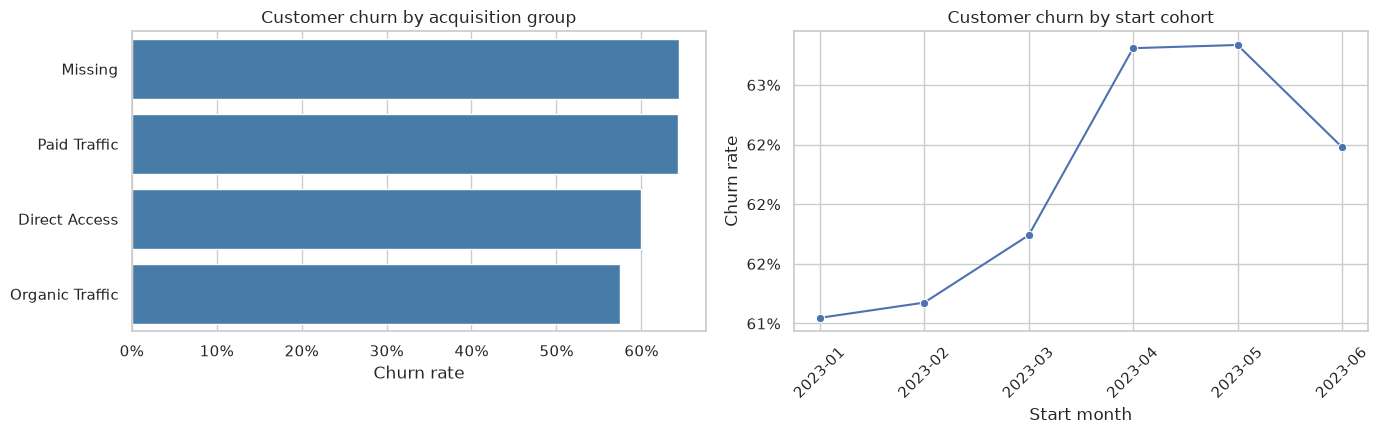

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

origin_plot = origin_summary.reset_index()
sns.barplot(data=origin_plot, x="churn_rate", y="origin_group", ax=axes[0], color="#377eb8")
axes[0].set(title="Customer churn by acquisition group", xlabel="Churn rate", ylabel="")
axes[0].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

cohort_plot = cohort_summary.sort_index().reset_index()
sns.lineplot(data=cohort_plot, x="customer_start_month", y="churn_rate", marker="o", ax=axes[1])
axes[1].set(title="Customer churn by start cohort", xlabel="Start month", ylabel="Churn rate")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

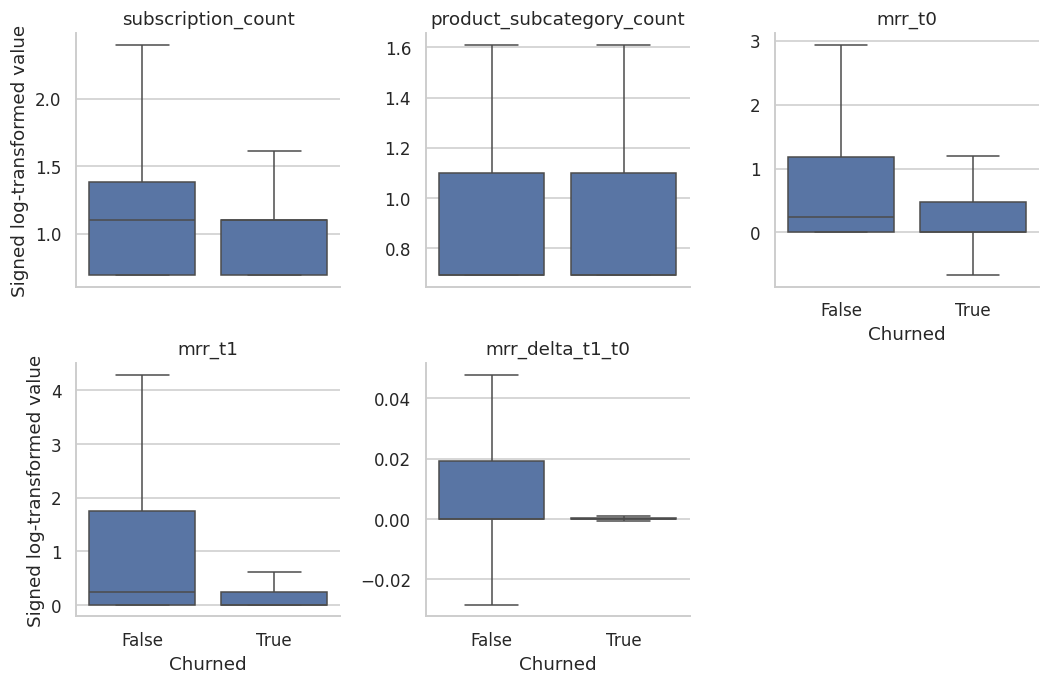

In [19]:
numeric_signals = [
    "subscription_count",
    "product_subcategory_count",
    "mrr_t0",
    "mrr_t1",
    "mrr_delta_t1_t0",
]
plot_data = train_customers[numeric_signals + ["target"]].copy()
for column in numeric_signals:
    # Signed log transform supports both positive MRR and credits/refunds.
    plot_data[column] = np.sign(plot_data[column]) * np.log1p(np.abs(plot_data[column]))

melted = plot_data.melt(id_vars="target", var_name="feature", value_name="signed_log_value")
g = sns.catplot(
    data=melted,
    x="target",
    y="signed_log_value",
    col="feature",
    col_wrap=3,
    kind="box",
    showfliers=False,
    sharey=False,
    height=3.2,
)
g.set_axis_labels("Churned", "Signed log-transformed value")
g.set_titles("{col_name}")
plt.tight_layout()

In [47]:
# A customer can own multiple product subcategories, so this is an exposure analysis:
# customers may contribute to more than one row in this table.
product_exposure = (
    train[[ID_COLUMN, "PRODUCT_SUBCATEGORY"]]
    .drop_duplicates()
    .merge(consistent_targets.rename("target").reset_index(), on=ID_COLUMN, how="inner")
)
product_churn = (
    product_exposure.groupby("PRODUCT_SUBCATEGORY")["target"]
    .agg(customers="size", churn_rate="mean")
    .query("customers >= 100")
    .sort_values("churn_rate", ascending=False)
)
product_churn

,customers,churn_rate
PRODUCT_SUBCATEGORY,,
Sitebuilder legacy,2741,0.646
E-mail,7928,0.626
Domain Names,22413,0.623
Shared Linux Hosting,435,0.469
WordPress Hosting,372,0.465


## 8. Training–validation shift

The validation customers start later than the training customers, so this is an out-of-time generalisation problem. Comparing customer-level feature distributions highlights where model performance may degrade.

In [51]:
comparison_features = [
    "row_count",
    "invoice_count",
    "subscription_count",
    "product_subcategory_count",
    "mrr_t0",
    "mrr_t1",
    "mrr_delta_t1_t0",
    "observed_t0",
    "observed_t1",
]

shift_summary = pd.DataFrame(
    {
        "train_mean": train_customers[comparison_features].mean(),
        "validation_mean": validation_customers[comparison_features].mean(),
        "train_median": train_customers[comparison_features].median(),
        "validation_median": validation_customers[comparison_features].median(),
        "train_sd": train_customers[comparison_features].std(),
        "validation_sd": validation_customers[comparison_features].std()
    }
)
shift_summary["relative_mean_change"] = (
    shift_summary["validation_mean"] - shift_summary["train_mean"]
) / shift_summary["train_mean"].replace(0, np.nan)
shift_summary["relative_sd"] = (
    1/2 * (shift_summary["validation_sd"] + shift_summary["train_sd"])
)
shift_summary

,train_mean,validation_mean,train_median,validation_median,train_sd,validation_sd,relative_mean_change,relative_sd
row_count,4.127,3.629,4.000,3.000,3.341,2.355,-0.121,2.848
invoice_count,2.325,2.099,2.000,2.000,1.705,1.588,-0.097,1.647
subscription_count,2.139,1.907,2.000,2.000,1.435,1.317,-0.108,1.376
product_subcategory_count,1.507,1.377,1.000,1.000,0.643,0.615,-0.087,0.629
mrr_t0,1.383,1.208,0.097,0.097,8.045,4.552,-0.126,6.299
mrr_t1,2.115,2.063,0.094,0.098,5.325,5.506,-0.025,5.416
mrr_delta_t1_t0,0.731,0.854,0.000,0.000,8.069,5.049,0.168,6.559
observed_t0,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000
observed_t1,0.995,0.997,1.000,1.000,0.067,0.059,0.001,0.063


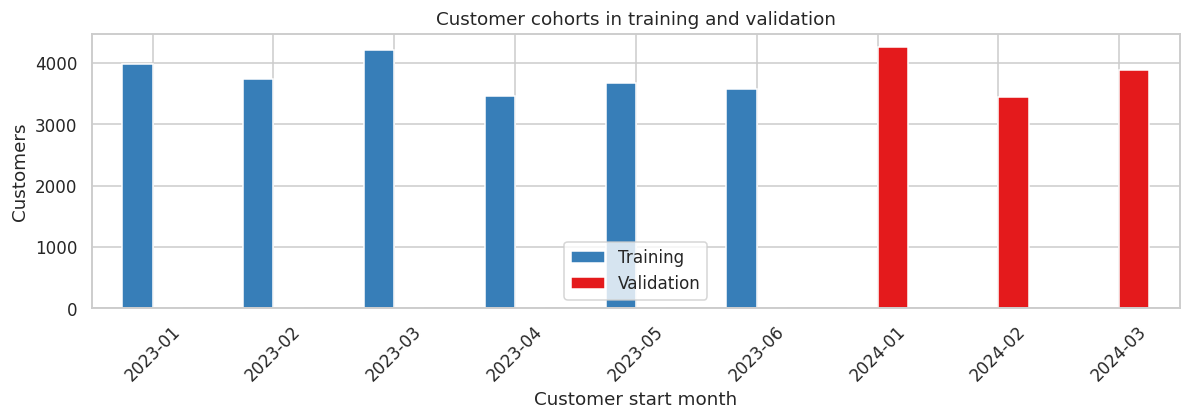

In [22]:
cohort_counts = pd.concat(
    {
        "Training": train_customers["customer_start_month"].value_counts(),
        "Validation": validation_customers["customer_start_month"].value_counts(),
    },
    axis=1,
).fillna(0).sort_index()

ax = cohort_counts.plot(kind="bar", figsize=(11, 4), color=["#377eb8", "#e41a1c"])
ax.set(title="Customer cohorts in training and validation", xlabel="Customer start month", ylabel="Customers")
plt.xticks(rotation=45)
plt.tight_layout()

## 9. Exploratory analysis findings

After the exploratory analysis we can conclude the following insights:

- Training contains **93,589 rows and 22,674 customer IDs**; validation contains **42,055 rows and 11,590 customer IDs**.
- Customer-level churn is approximately **62.1%**, compared with **58.9%** when incorrectly calculated across rows. This confirms that row-level evaluation would be biased by customer activity.
- One customer ID has conflicting target values and will be excluded from the forecast, as there is no further information about this event.
- Training has **1,467 negative-tenure rows across 30 customers**, despite the brief defining tenure as 0 or 1. There doesn't seem to be any relationship between other variables and the missingness of this 1467 rows, which means they are Missing Completely at Random (MCAR), so it will make sense to discard all these rows to avoid biases.
- There are negative MRR values which might be consistent with credits or refunds; signed changes and robust transformations are preferable to dropping them.
- Acquisition channel, business/private status, product mix, MRR trajectory, and product/subscription counts all merit evaluation as early-life predictors.
- Training cohorts run from January–June 2023, while validation cohorts run from January–March 2024. Internal model selection should therefore include an **out-of-time holdout**, not only a random split.
- Some product categories appear in only one dataset. A safe encoder must handle missing and unseen categories.
- Raw customer, invoice, and subscription IDs should be excluded from model inputs. They are useful for grouping and output only.